In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42

In [4]:
X_train = pd.read_csv('..\..\..\data\processed\splits\X_train.csv')
X_val   = pd.read_csv('..\..\..\data\processed\splits\X_val.csv')
X_test  = pd.read_csv('..\..\..\data\processed\splits\X_test.csv')

y_clf_train = pd.read_csv('..\..\..\data\processed\splits\y_clf_train.csv').squeeze()
y_clf_val   = pd.read_csv('..\..\..\data\processed\splits\y_clf_val.csv').squeeze()
y_clf_test  = pd.read_csv('..\..\..\data\processed\splits\y_clf_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (1953, 20)
X_val   : (419, 20)
X_test  : (419, 20)


In [5]:
# map label: -1→0, 0→1, 1→2
LABEL_MAP     = {-1.0: 0, 0.0: 1, 1.0: 2}
LABEL_MAP_INV = {0: -1, 1: 0, 2: 1}
LABEL_NAMES   = ['Down (-1)', 'Side (0)', 'Up (1)']

y_train = y_clf_train.map(LABEL_MAP).astype(int)
y_val   = y_clf_val.map(LABEL_MAP).astype(int)
y_test  = y_clf_test.map(LABEL_MAP).astype(int)

# คำนวณ sample_weight จาก train set เท่านั้น
sample_weights = compute_sample_weight('balanced', y_train)

print('Class distribution (train):')
for i, name in enumerate(LABEL_NAMES):
    print(f'  {name}: {(y_train == i).sum()} samples')

Class distribution (train):
  Down (-1): 433 samples
  Side (0): 1030 samples
  Up (1): 490 samples


In [6]:
def objective(trial):
    params = {
        'objective'        : 'multi:softprob',
        'num_class'        : 3,
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'eval_metric'      : 'mlogloss',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
    }
    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight = sample_weights,
        eval_set      = [(X_val, y_val)],
        verbose       = False
    )
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='macro')

study = optuna.create_study(direction='maximize', study_name='xgb_clf_gold')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'Best Macro F1 (val): {study.best_value:.4f}')
print('Best params:', study.best_params)

Best trial: 63. Best value: 0.418082: 100%|██████████| 80/80 [02:29<00:00,  1.86s/it]

Best Macro F1 (val): 0.4181
Best params: {'n_estimators': 559, 'learning_rate': 0.17211406305328697, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.5629547680381822, 'colsample_bytree': 0.7227727832532734, 'gamma': 0.6575858719676566, 'reg_alpha': 0.013074006947670653, 'reg_lambda': 0.00010525541996612883}


In [8]:
best_params = study.best_params
best_params.update({
    'objective'   : 'multi:softprob',
    'num_class'   : 3,
    'eval_metric' : 'mlogloss',
    'random_state': RANDOM_STATE,
    'n_jobs'      : -1,
})

best_clf = XGBClassifier(**best_params)
best_clf.fit(
    X_train, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_val, y_val)],
    verbose       = False
)
print('Training complete!')

Training complete!



===== Validation =====
Accuracy   : 0.4630
F1 Macro   : 0.4181
F1 Weighted: 0.4708

              precision    recall  f1-score   support

   Down (-1)       0.23      0.31      0.27        85
    Side (0)       0.62      0.57      0.59       215
      Up (1)       0.41      0.38      0.39       119

    accuracy                           0.46       419
   macro avg       0.42      0.42      0.42       419
weighted avg       0.48      0.46      0.47       419



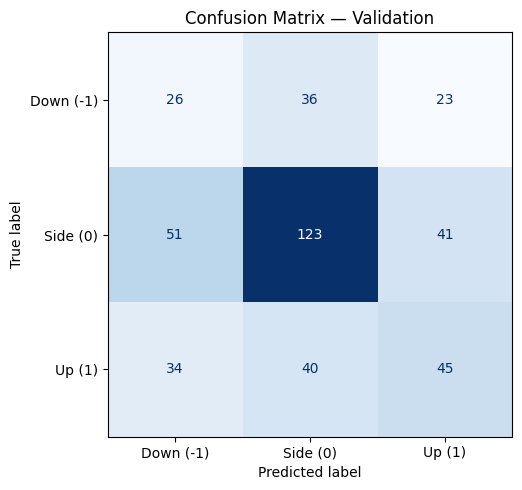


===== Test =====
Accuracy   : 0.3675
F1 Macro   : 0.3649
F1 Weighted: 0.3684

              precision    recall  f1-score   support

   Down (-1)       0.29      0.41      0.34       105
    Side (0)       0.40      0.31      0.35       151
      Up (1)       0.41      0.39      0.40       163

    accuracy                           0.37       419
   macro avg       0.37      0.37      0.36       419
weighted avg       0.38      0.37      0.37       419



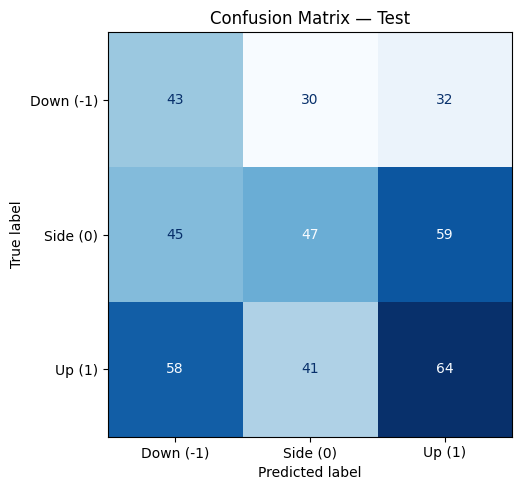

In [9]:
def evaluate(model, X, y_true, split_name='Val'):
    preds = model.predict(X)

    print(f'\n===== {split_name} =====')
    print(f'Accuracy   : {accuracy_score(y_true, preds):.4f}')
    print(f'F1 Macro   : {f1_score(y_true, preds, average="macro"):.4f}')
    print(f'F1 Weighted: {f1_score(y_true, preds, average="weighted"):.4f}')
    print()
    print(classification_report(y_true, preds, target_names=LABEL_NAMES))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_true, preds), display_labels=LABEL_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {split_name}')
    plt.tight_layout()
    # plt.savefig(f'/confusion_matrix_{split_name.lower()}.png', dpi=150)
    plt.show()

evaluate(best_clf, X_val,  y_val,  'Validation')
evaluate(best_clf, X_test, y_test, 'Test')

In [10]:
test_preds = best_clf.predict(X_test)

df_out = pd.DataFrame({
    'clf_pred': [LABEL_MAP_INV[p] for p in test_preds],
})

df_out.to_csv('clf_xg.csv', index=False)
print('Saved!')

Saved!
